# 0. Libraries & Settings

In [1]:
%load_ext autoreload
%autoreload 2

from car_price_model.data_io.reading import read_data_from_directory
import car_price_model.data_io.reading as reading
from matplotlib import pyplot as plt
from car_price_model.processing.outliers import remove_outliers_iqr, trim_outliers, remove_top_n_outliers
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import sublimeplot as sp
import matplotlib
from scipy.stats import gaussian_kde
import math


In [2]:
# Settings
sp.config.fontname = "IBM Plex Sans"
pd.set_option('display.max_columns', None)


# 1. Reading data

- Data is read with `read_dataset` function from file [listings.parquet](../data/interim/listings.parquet)
- Data has already been mapped, cleaned and preprocessed. For more information, see  [cleaning.py](../src/car_price_model/processing/cleaning.py)

In [3]:
df = reading.read_dataset("data/interim/listings.parquet")
df.head()

,age,cv,km,fuel,doors,gearbox,emissions,color,brand,price,boot,length,height,width,seats,max_sp,cmixto,curban,extraurban,zero_to_hundred,displac,max_par,gear,class,location,n_cylinders,cylinder_layout
0,5,184,74,gasoline,2,automatic,129,blue,mercedes,37900,400,469,141,181,4,235,5.8,7.5,4.7,7.3,1991,300,9,sport,[islas baleares],4,inline
1,3,122,58,gasoline,4,automatic,126,black,mercedes,32990,470,463,143,178,5,210,5.5,7.1,4.6,8.7,1595,200,7,sport,[islas baleares],4,inline
2,7,110,67,diesel,2,manual,112,gray,volkswagen,22790,225,428,147,181,4,180,4.3,5.0,4.1,11.7,1968,250,5,sport,[islas baleares],4,inline
3,12,200,47,gasoline,2,manual,155,gray,peugeot,21900,321,429,136,185,4,237,6.9,8.8,5.6,7.5,1598,275,6,sport,[islas baleares],4,inline
4,6,140,49,gasoline,2,manual,149,blue,opel,17990,280,470,144,184,4,207,6.3,7.8,5.4,10.9,1362,200,6,sport,[islas baleares],4,inline


### 1.1 Table Schema


This dataset contains **51,074** car listings scraped from [coches.com](https://coches.com) in **2023**, where **each row is an individual listing** for a used vehicle. Each listing includes vehicle specifications (power, dimensions, fuel consumption, emissions, engine details), descriptive attributes (brand, color, class, year), and the listing price. The location field is list-like because a single listing can be published in multiple locations simultaneously.


| Variable | Type | Description | Units/Example |
|----------|------|-------------|---------------|
| `age` | int64 | Age of the vehicle | e.g. `2018` |
| `cv` | int64 | Engine power in *caballos de vapor* | e.g. `184` |
| `km` | int64 | Mileage of the vehicle (in thousands of km) | e.g. `74` |
| `fuel` | object | Fuel type | `gasoline`, `diesel` |
| `doors` | int64 | Number of doors | `2`, `4`, `5` |
| `gearbox` | object | Transmission type | `automatic`, `manual` |
| `emissions` | int64 | CO₂ emissions | g/km, e.g. `129` |
| `color` | object | Exterior color | `blue`, `black`, `gray` |
| `brand` | object | Manufacturer | `mercedes`, `opel` |
| `price` | int64 | Listing price | euros (€), e.g. `37900` |
| `boot` | int64 | Boot/trunk capacity | liters, e.g. `400` |
| `length` | int64 | Vehicle length | cm, e.g. `469` |
| `height` | int64 | Vehicle height | cm, e.g. `141` |
| `width` | int64 | Vehicle width | cm, e.g. `181` |
| `seats` | int64 | Number of seats | e.g. `5` |
| `max_sp` | int64 | Maximum speed | km/h, e.g. `235` |
| `cmixto` | float64 | Combined fuel consumption | L/100km, e.g. `5.8` |
| `curban` | float64 | Urban fuel consumption | L/100km, e.g. `7.5` |
| `extraurban` | float64 | Extra-urban (highway) fuel consumption | L/100km, e.g. `4.7` |
| `zero_to_hundred` | float64 | Acceleration time from 0 to 100 km/h | seconds, e.g. `7.3` |
| `displac` | int64 | Engine displacement | cc, e.g. `1991` |
| `max_par` | int64 | Maximum torque (*par máximo*) | Nm, e.g. `300` |
| `gear` | int64 | Number of gears | e.g. `9` |
| `class` | object | Vehicle class/segment | `sport` |
| `location` | object | Location(s) where listing is published (list; can be multiple) | `[islas baleares]` |
| `n_cylinders` | int64 | Number of cylinders | e.g. `4` |
| `cylinder_layout` | object | Cylinder configuration | `inline` |



# 2. Data Quality Assestment

In [4]:
print(f"Null values have already been removed, {df.isnull().sum().sum()} null values found")
print(f"After deduplication: {len(df):,} rows remain with {len(df)-len(df.drop(columns=['location']).drop_duplicates())} current duplicates")

Null values have already been removed, 0 null values found
After deduplication: 52,239 rows remain with 0 current duplicates


In [5]:
df.describe()

,age,cv,km,doors,emissions,price,boot,length,height,width,seats,max_sp,cmixto,curban,extraurban,zero_to_hundred,displac,max_par,gear,n_cylinders
count,52239.000000,52239.000000,52239.000000,52239.000000,52239.000000,52239.000000,52239.000000,52239.000000,52239.000000,52239.000000,52239.00000,52239.000000,52239.000000,52239.000000,52239.000000,52239.000000,52239.000000,52239.000000,52239.000000,52239.000000
mean,5.941481,140.257662,83.606979,4.733800,123.050135,21702.142403,433.243458,437.056778,154.303873,180.853998,4.97433,195.914068,5.007582,6.049806,4.332189,10.073361,1669.632076,287.033117,6.052815,3.921400
std,3.654752,61.628720,62.825852,0.691548,32.692118,14349.722681,149.540726,31.731856,10.780293,7.311909,0.52278,22.722497,1.357669,2.066894,1.098382,2.604427,546.631246,317.682937,1.306193,0.747077
min,0.000000,41.000000,1.000000,2.000000,0.000000,500.000000,32.000000,250.000000,114.000000,150.000000,2.00000,118.000000,1.100000,0.000000,0.000000,0.000000,698.000000,0.000000,1.000000,2.000000
25%,4.000000,109.000000,39.000000,5.000000,105.000000,13900.000000,350.000000,417.000000,146.000000,177.000000,5.00000,181.000000,4.200000,4.800000,3.700000,8.900000,1364.000000,200.000000,5.000000,4.000000
50%,5.000000,130.000000,73.000000,5.000000,116.000000,18990.000000,420.000000,438.000000,151.000000,181.000000,5.00000,192.000000,4.800000,5.700000,4.100000,10.400000,1560.000000,250.000000,6.000000,4.000000
75%,7.000000,150.000000,114.000000,5.000000,133.000000,25990.000000,510.000000,459.000000,162.000000,184.000000,5.00000,208.000000,5.500000,6.700000,4.800000,11.500000,1969.000000,330.000000,6.000000,4.000000
max,54.000000,720.000000,994.000000,5.000000,495.000000,565000.000000,2500.000000,540.000000,200.000000,224.000000,9.00000,350.000000,21.300000,31.000000,15.000000,20.000000,6592.000000,12164.000000,10.000000,12.000000


All extreme values (both min and max) fall in reasonable ranges. There might be some exceptions on the following columns `emissions`, `curban`, `extraurban`, `zero_to_hundred`, `seats`, `doors`, `height`, `max_par` but it won't be problematic since those columns are being dropped after checking their correlation.

# 3. Correlation with target `price` 

In [6]:
# move price to the end 
df = df[[col for col in df.columns if col != 'price'] + ['price']]

In [7]:
def plot_correlation_matrix(df, full_matrix=True):
    plt.figure(figsize=(14,10*full_matrix+1))
    corr = df.select_dtypes(np.number).corr().round(2)
    if not full_matrix:
        corr = corr.iloc[[-1]]
    sns.heatmap(corr, annot=True, cmap='RdBu', center = 0, vmin=-1, vmax=1)
    sns.set_theme(font="IBM Plex Sans")
    plt.show()
    matplotlib.rc_file_defaults()

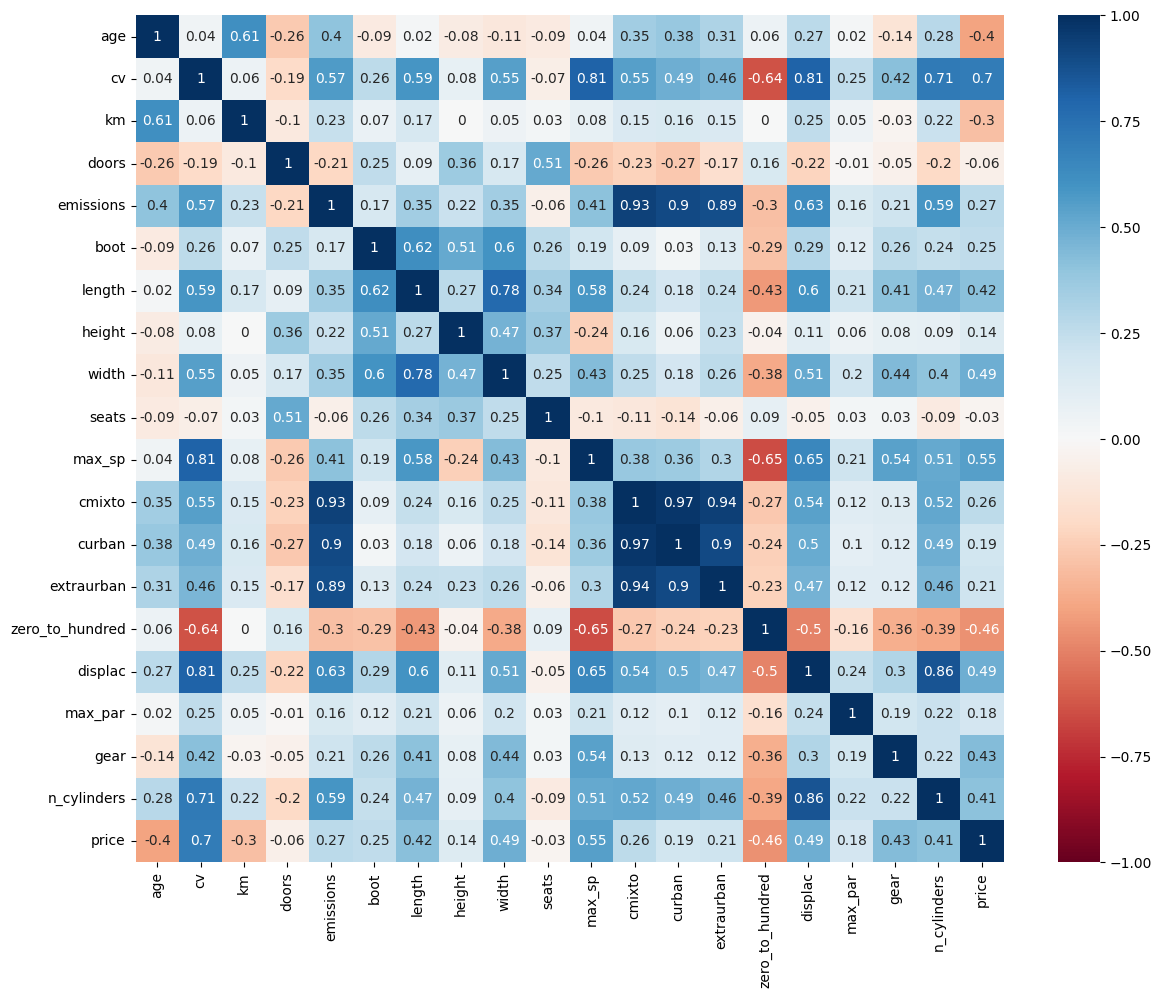

In [8]:
plot_correlation_matrix(df)


I will be dropping the columns `curban`, `extraurban`, `seats`, `doors`, `height` and `max_par` because they have a low correlation with the target **price** as we can see below:

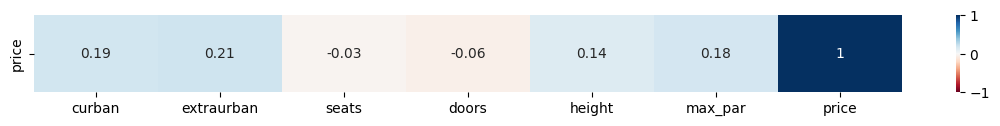

In [9]:
columns = ["curban", "extraurban", "seats", "doors", "height", "max_par","price"]
plot_correlation_matrix(df[columns], full_matrix=False)

I will also be droppin the columns `emissions`, `zero_to_hundred` since they are heavily correlated to other existing columns like `cmixto`, `max_sp`

In [10]:
# plot_correlation_matrix(df[["emissions","cmixto", "zero_to_hundred", "max_sp"]], full_matrix=True)

In [11]:
cols_to_drop = ["emissions", "curban", "extraurban", "seats", "doors", "height", "max_par", "zero_to_hundred"]
df = df.drop(cols_to_drop, axis=1)

This leaves us 20 columns, with a cleaner correlation matrix that looks like this:

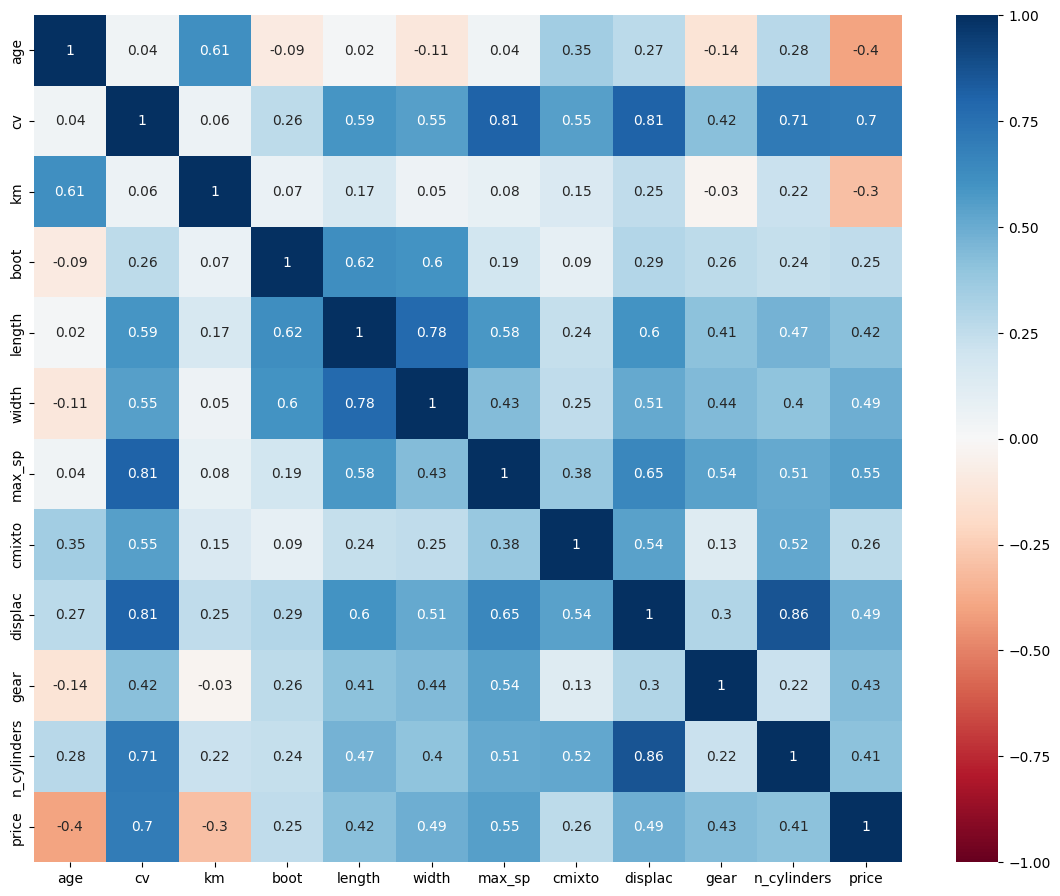

In [12]:
plot_correlation_matrix(df)

**Takeaways on `Price`**:
- Engine power (cv) is the strongest linear predictor of price.
- Higher-priced cars tend to be (logically):
    - more powerful,
    - faster (higher max speed),
    - larger (width and length),
    - equipped with larger engines (displacement, cylinders).
- Older vehicles and vehicles with higher mileage tend to have lower prices.
- I initially thought mileage was more important than age in depreciation, but apparently, the later appears to have a stronger signal.

**Takeaways on Multicollinearity**:

Several varaibles are measuring similar concepts, as we can see in the following table:
| Pair                     |  Corr |
| ------------------------ | ----: |
| cv ↔ max_sp              |  0.81 |
| cv ↔ displac             |  0.81 |
| displac ↔ n_cylinders    |  0.86 |
| cv ↔ n_cylinders         |  0.71 |

Since we are going for a tree-based model, we will keep all these variables. If we were to find model overfitting during validation, we could consider removing some of them to improve the generalization.

# 4. Univariate Analysis & Outlier detection

In [13]:
def kde_curve(data, bw_adjust=1.0, gridsize=1000):
    """Compute a KDE curve for plotting."""
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    kde = gaussian_kde(data)
    kde.set_bandwidth(kde.factor * bw_adjust)
    x = np.linspace(data.min(), data.max(), gridsize)
    return x, kde(x)

def plot_histogram(series, bins=None, color_1="skyblue", color_2="darkblue", bw_adjust=1.0, plot_kde=True):
    var = series.name
    ax = series.hist(bins=bins, density=True, zorder=2, color=color_1, edgecolor="white")
    if plot_kde:
        plt.plot(*kde_curve(series, bw_adjust=bw_adjust), zorder=2, color=color_2, alpha=0.85, linewidth=2)
    return ax

### 4.1. Numerical Variables.

For our target variable `price`, there's a decent amount of outliers on the higher end (up to half a million euros, cars that really don't belong in this dataset). As we can see below, the distribution is heavily right-skewed, following a **log-normal pattern**. The same happens to the `boot` capacity column, although not as severe.

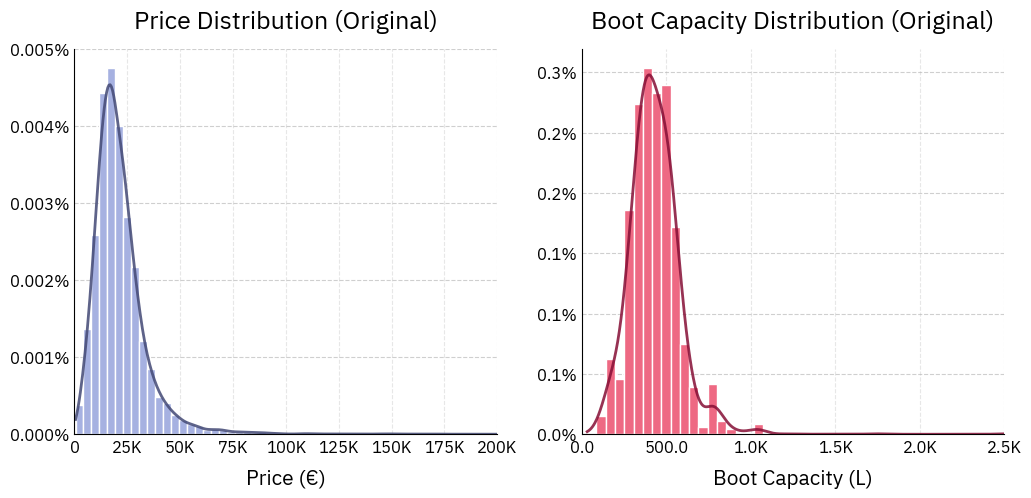

In [14]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
color_1, color_2, var = "#A6B1E1", "#424874", "price"
ax = df[var].hist(bins=150, density=True, zorder=2, color=color_1, edgecolor="white")
plt.plot(*kde_curve(df[var], bw_adjust=1.5), zorder=2, color=color_2, alpha=0.85, linewidth=2)
title, xtitle = "Price Distribution (Original)", "Price (€)"
sp.style_hist(ax, yformat=sp.formats.percent(decimals=3), xformat=sp.formats.human(decimals=0), xtitle=xtitle, title=title)
plt.xlim(0, 200000)

plt.subplot(1, 2, 2)
color_1, color_2, var = "#EE6983", "#850E35", "boot"
ax = df[var].hist(bins=45, density=True, zorder=2, color=color_1, edgecolor="white")
plt.plot(*kde_curve(df[var], bw_adjust=3), zorder=2, color=color_2, alpha=0.85, linewidth=2)
sp.style_hist(ax, yformat=sp.formats.percent(decimals=1), xformat=sp.formats.human(decimals=1), xtitle="Boot Capacity (L)", title="Boot Capacity Distribution (Original)")
plt.xlim(0, df[var].max())
plt.show()


Since these distributions behave like a log-normal distribution, a **traditional IQR outlier detection method is not going to be the best approach** (it would remove too many data points). 

Instead, we will use the **trimming method** to **remove the top 1%** of the data.

In [15]:
df = trim_outliers(df, "price", upper_quantile=0.99)
df = trim_outliers(df, "boot", upper_quantile=0.99)

After the outlier trimming we got a more reasonable distribution of prices and car boot sizes (which is consistent with our decision in `cleaning.py` to filter out commercial vehicles because of their low volume).

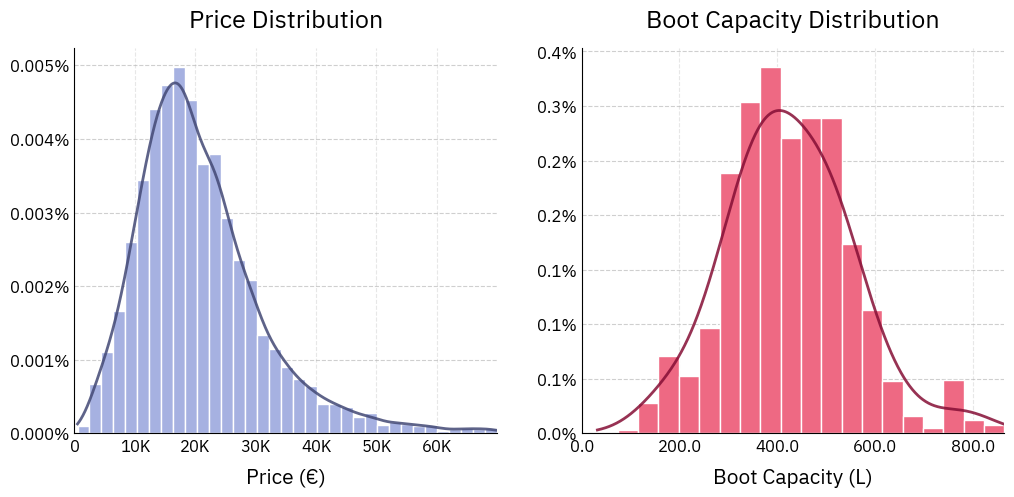

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
ax = plot_histogram(df["price"], bins=35, color_1="#A6B1E1", color_2="#424874", bw_adjust=1.5)
title, xtitle = "Price Distribution", "Price (€)"
sp.style_hist(ax, yformat=sp.formats.percent(decimals=3), xformat=sp.formats.human(decimals=0), xtitle=xtitle, title=title)
plt.xlim(0, df["price"].max())

plt.subplot(1, 2, 2)
ax = plot_histogram(df["boot"], bins=20, color_1="#EE6983", color_2="#850E35", bw_adjust=4)
sp.style_hist(ax, yformat=sp.formats.percent(decimals=1), xformat=sp.formats.human(decimals=1), xtitle="Boot Capacity (L)", title="Boot Capacity Distribution")
plt.xlim(0, df["boot"].max())
plt.show()


For the rest of numerical values, we can see that they are quite naturally distributed. There are always extreme values, but they look like legitimate data points. 

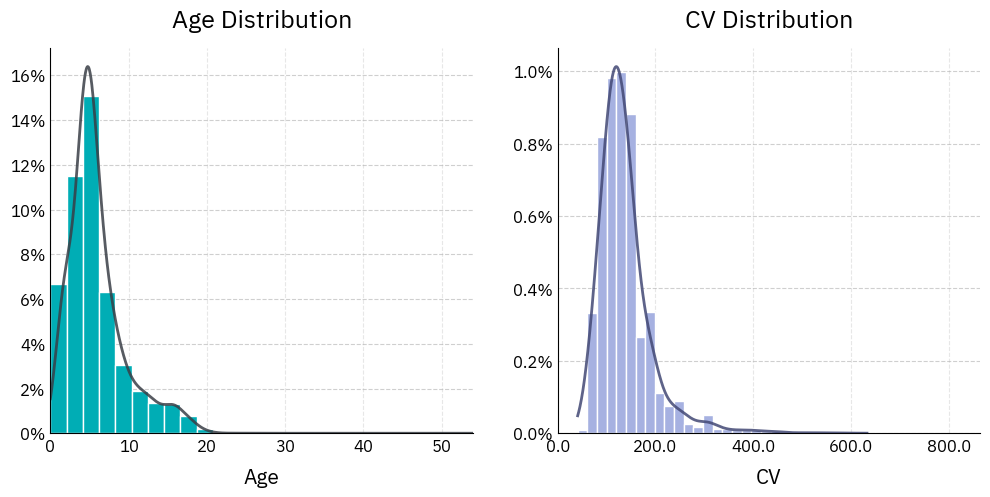

In [17]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
ax = plot_histogram(df["age"], bins=26, color_1="#00ADB5", color_2="#393E46", bw_adjust=2)
sp.style_hist(ax, yformat=sp.formats.percent(decimals=0), xformat=sp.formats.human(decimals=0), xtitle="Age", title="Age Distribution")
plt.xlim(0, df["age"].max())

plt.subplot(1, 2, 2)
ax = plot_histogram(df["cv"], bins=30, color_1="#A6B1E1", color_2="#424874", bw_adjust=3)
sp.style_hist(ax, yformat=sp.formats.percent(decimals=1), xformat=sp.formats.human(decimals=1), xtitle="CV", title="CV Distribution")
plt.xlim(0, df[var].max())
plt.show()


There is only **one exception** that stands out: one car with an **age greater than 50 years**, so far from the distribution that makes no sense to keep it.

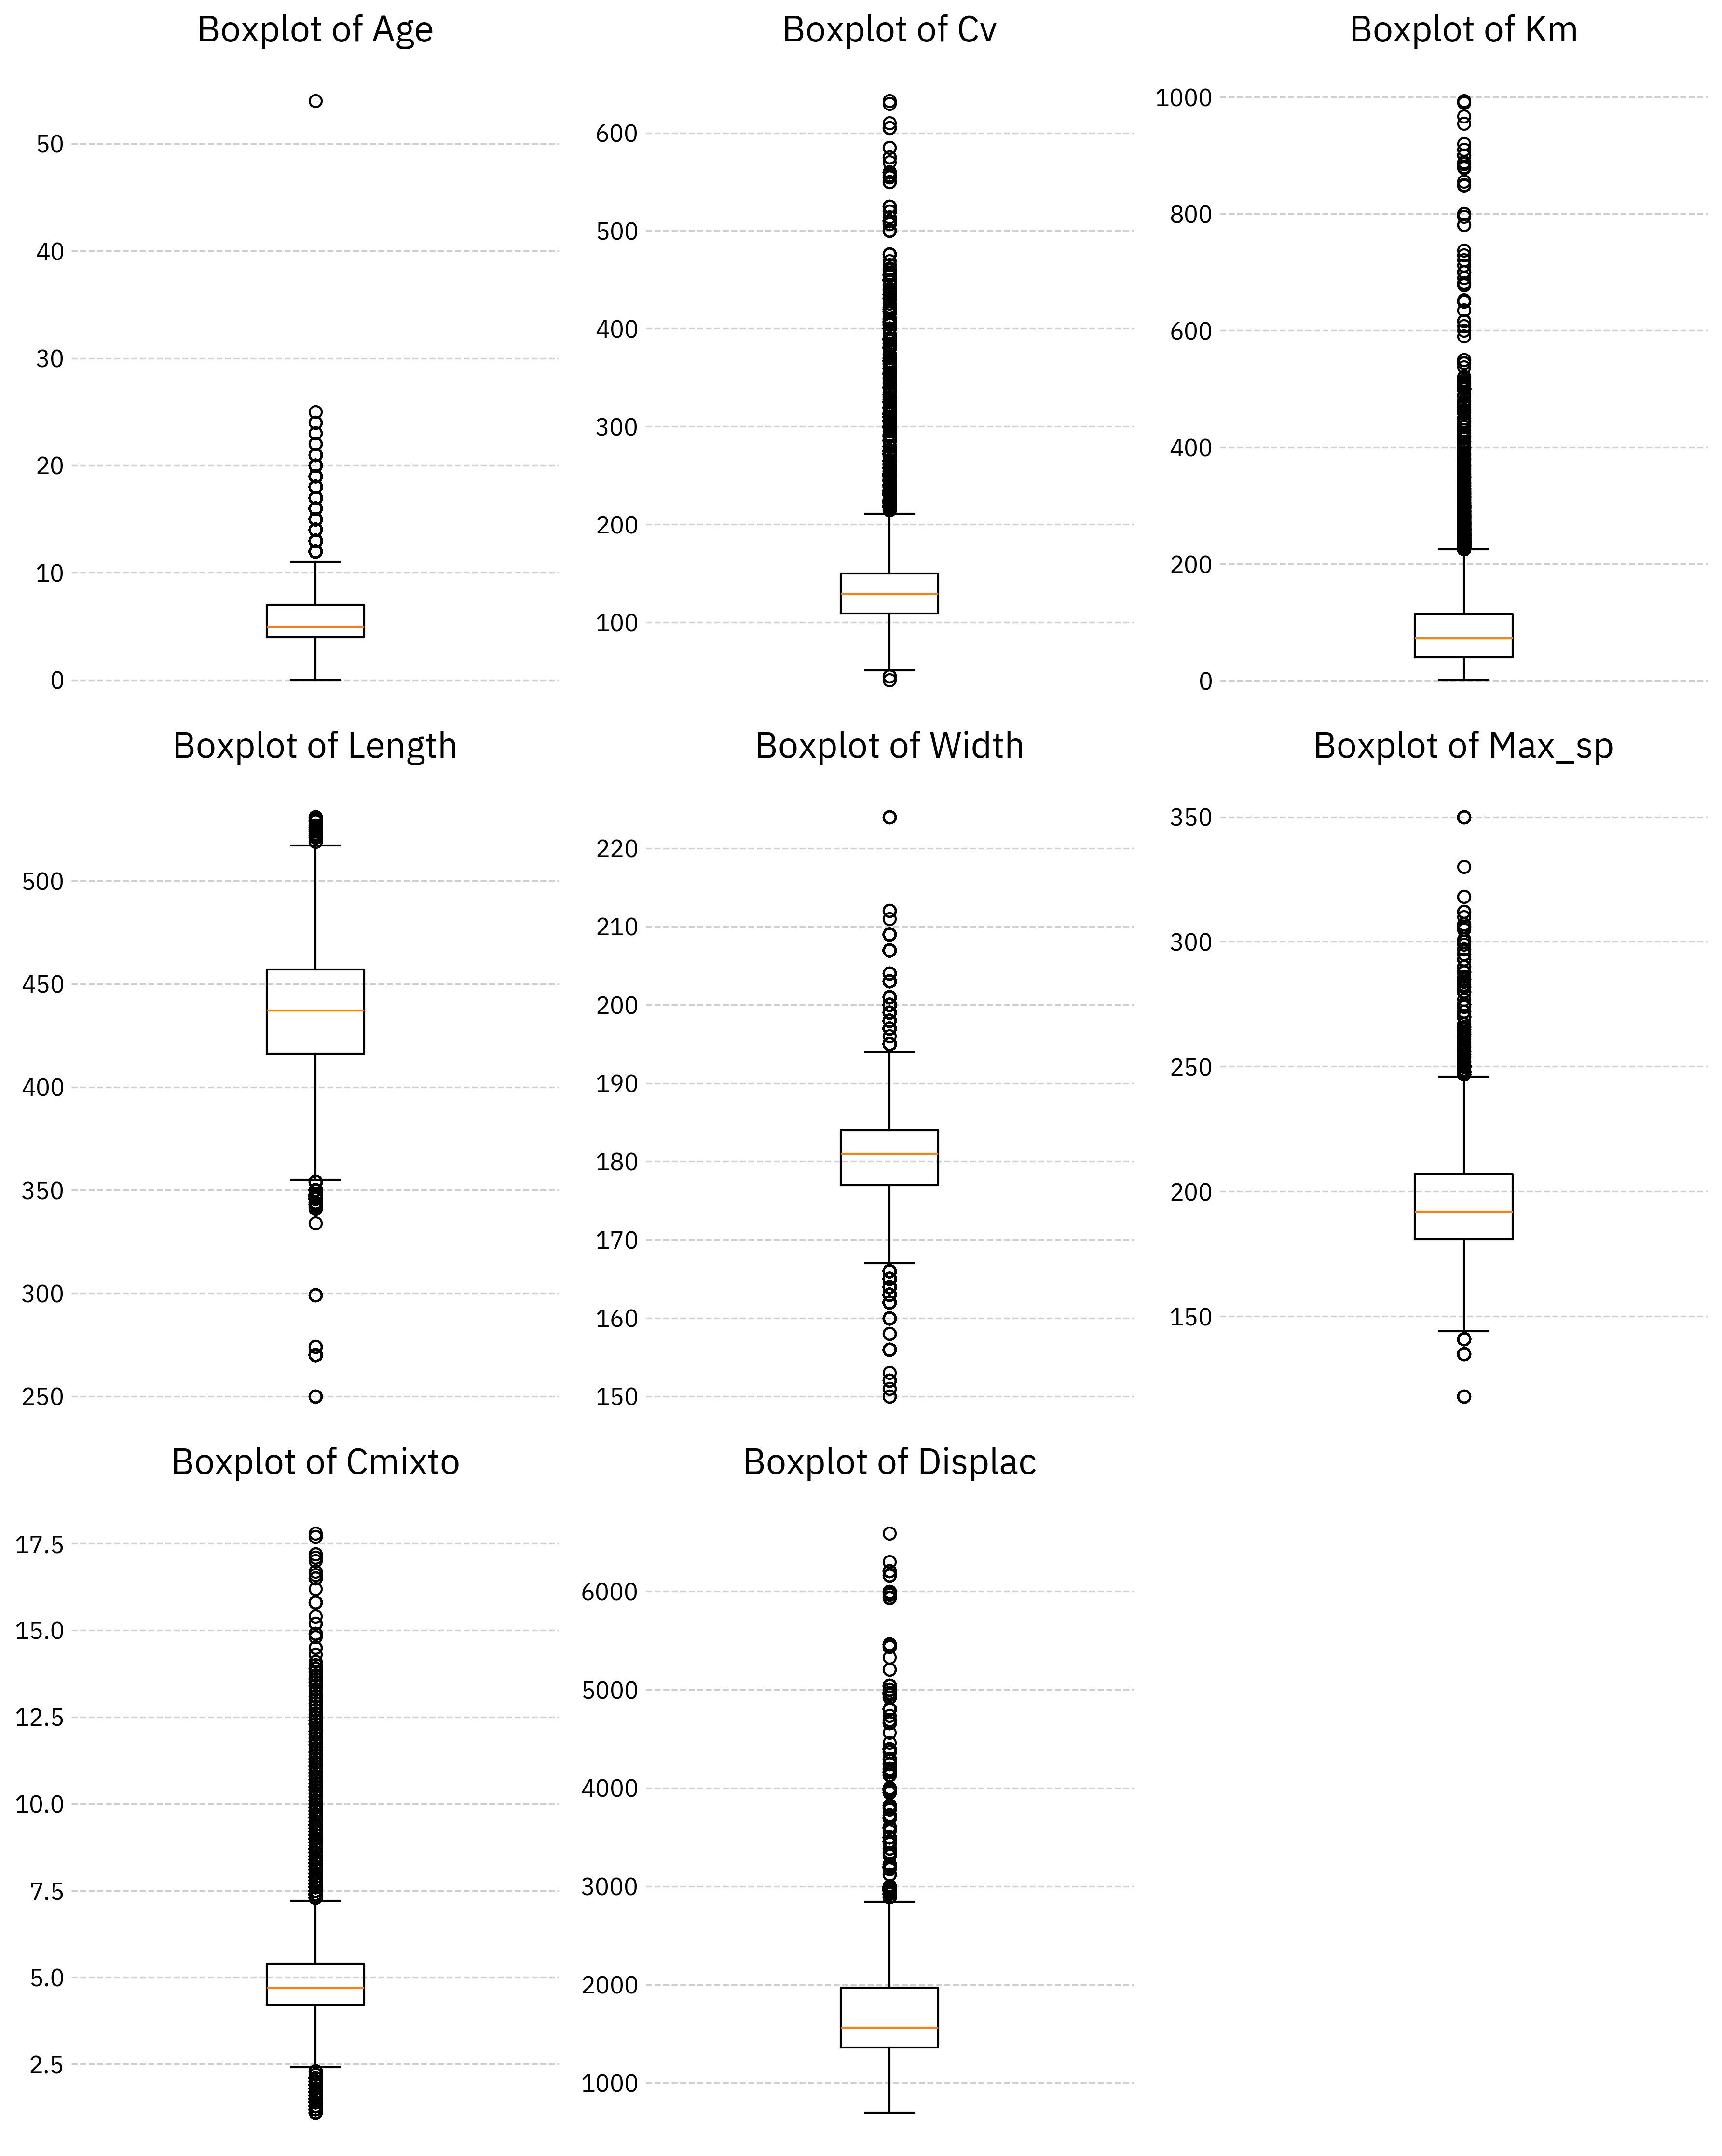

In [18]:

columns = ["age", "cv", "km", "length", "width", "max_sp", "cmixto", "displac"]
n_cols = 3 
n_rows = math.ceil(len(columns) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 5), dpi=300)
axes = axes.flatten()
for i, col in enumerate(columns):
    ax = axes[i]  
    ax.boxplot(df[col], widths=0.2)
    plt.ylim(0, df[col].max()*1.1)
    sp.style_box(ax, title=f"Boxplot of {col.capitalize()}")
for j in range(len(columns), len(axes)):
    fig.delaxes(axes[j])

sp.config.fontname = "IBM Plex Sans"
plt.tight_layout()  
plt.show()

In [19]:
df = remove_top_n_outliers(df, "age", 1)

### 4.2. Categorical Variables.

For categorical variables, we can use a box plot to visualize the distribution of frequency for each category.

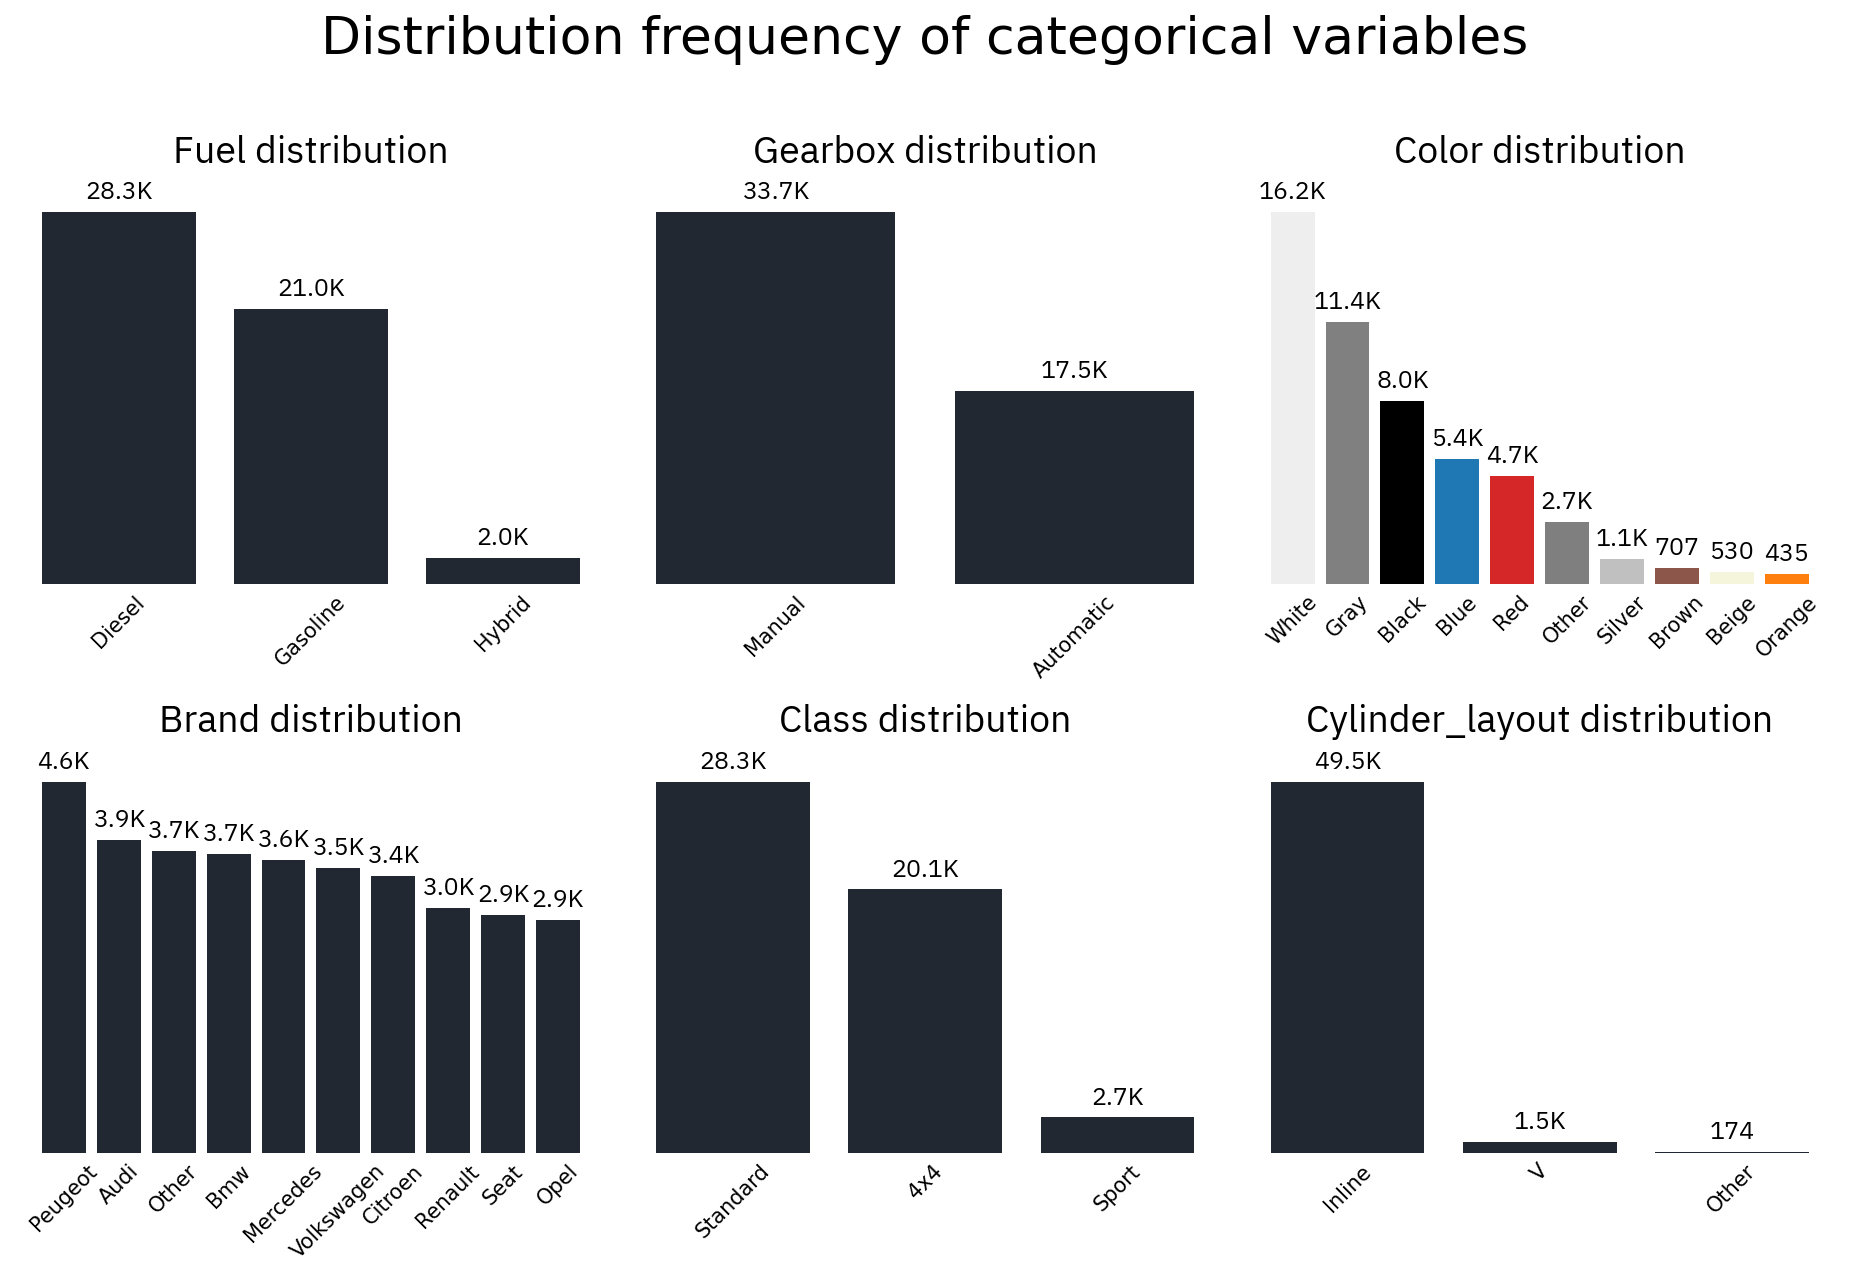

In [20]:

cats = [c for c in df.columns if (df[c].dtype == "object") and (c != "location")] 
n_cols = 3
n_rows = math.ceil(len(cats) / n_cols)

color_map = {
    "White": "#EEEEEE",
    "Gray": "#808080",
    "Black": "#000000",
    "Blue": "#1F77B4",
    "Red": "#D62728",
    "Other": "#7F7F7F",
    "Silver": "#C0C0C0",
    "Brown": "#8C564B",
    "Beige": "#F5F5DC",
    "Orange": "#FF7F0E",
}
default_color = "#222831"

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4.15, n_rows * 4.15),dpi=150)
axes = axes.flatten() if len(cats) > 1 else [axes]
plt.suptitle("Distribution frequency of categorical variables", fontsize=25, y=1.02)
for i, col in enumerate(cats):
    # Slice the top 10 value counts here
    counts = df[col].value_counts().head(10)
    categories = counts.index.astype(str).str.capitalize()
    if col == "color":
        colors = [color_map.get(cat, default_color) for cat in categories]
        bars = axes[i].bar(categories, counts, color=colors)
    else:
        bars = axes[i].bar(categories, counts, color=default_color)

    sp.style_bar(axes[i], title=f"{col.capitalize()} distribution", fmt=sp.formats.human(decimals=1, plain_decimals=0))
    axes[i].tick_params(axis="x", labelrotation=45)

for j in range(len(cats), len(axes)):
    fig.delaxes(axes[j])

sp.config.fontname = "IBM Plex Sans"
plt.tight_layout()
plt.show()

# 5. Bivariate Analysis with target `price`

We can also look at the price distribution for each category, which is a quick way to see relationships between the categories and the price.

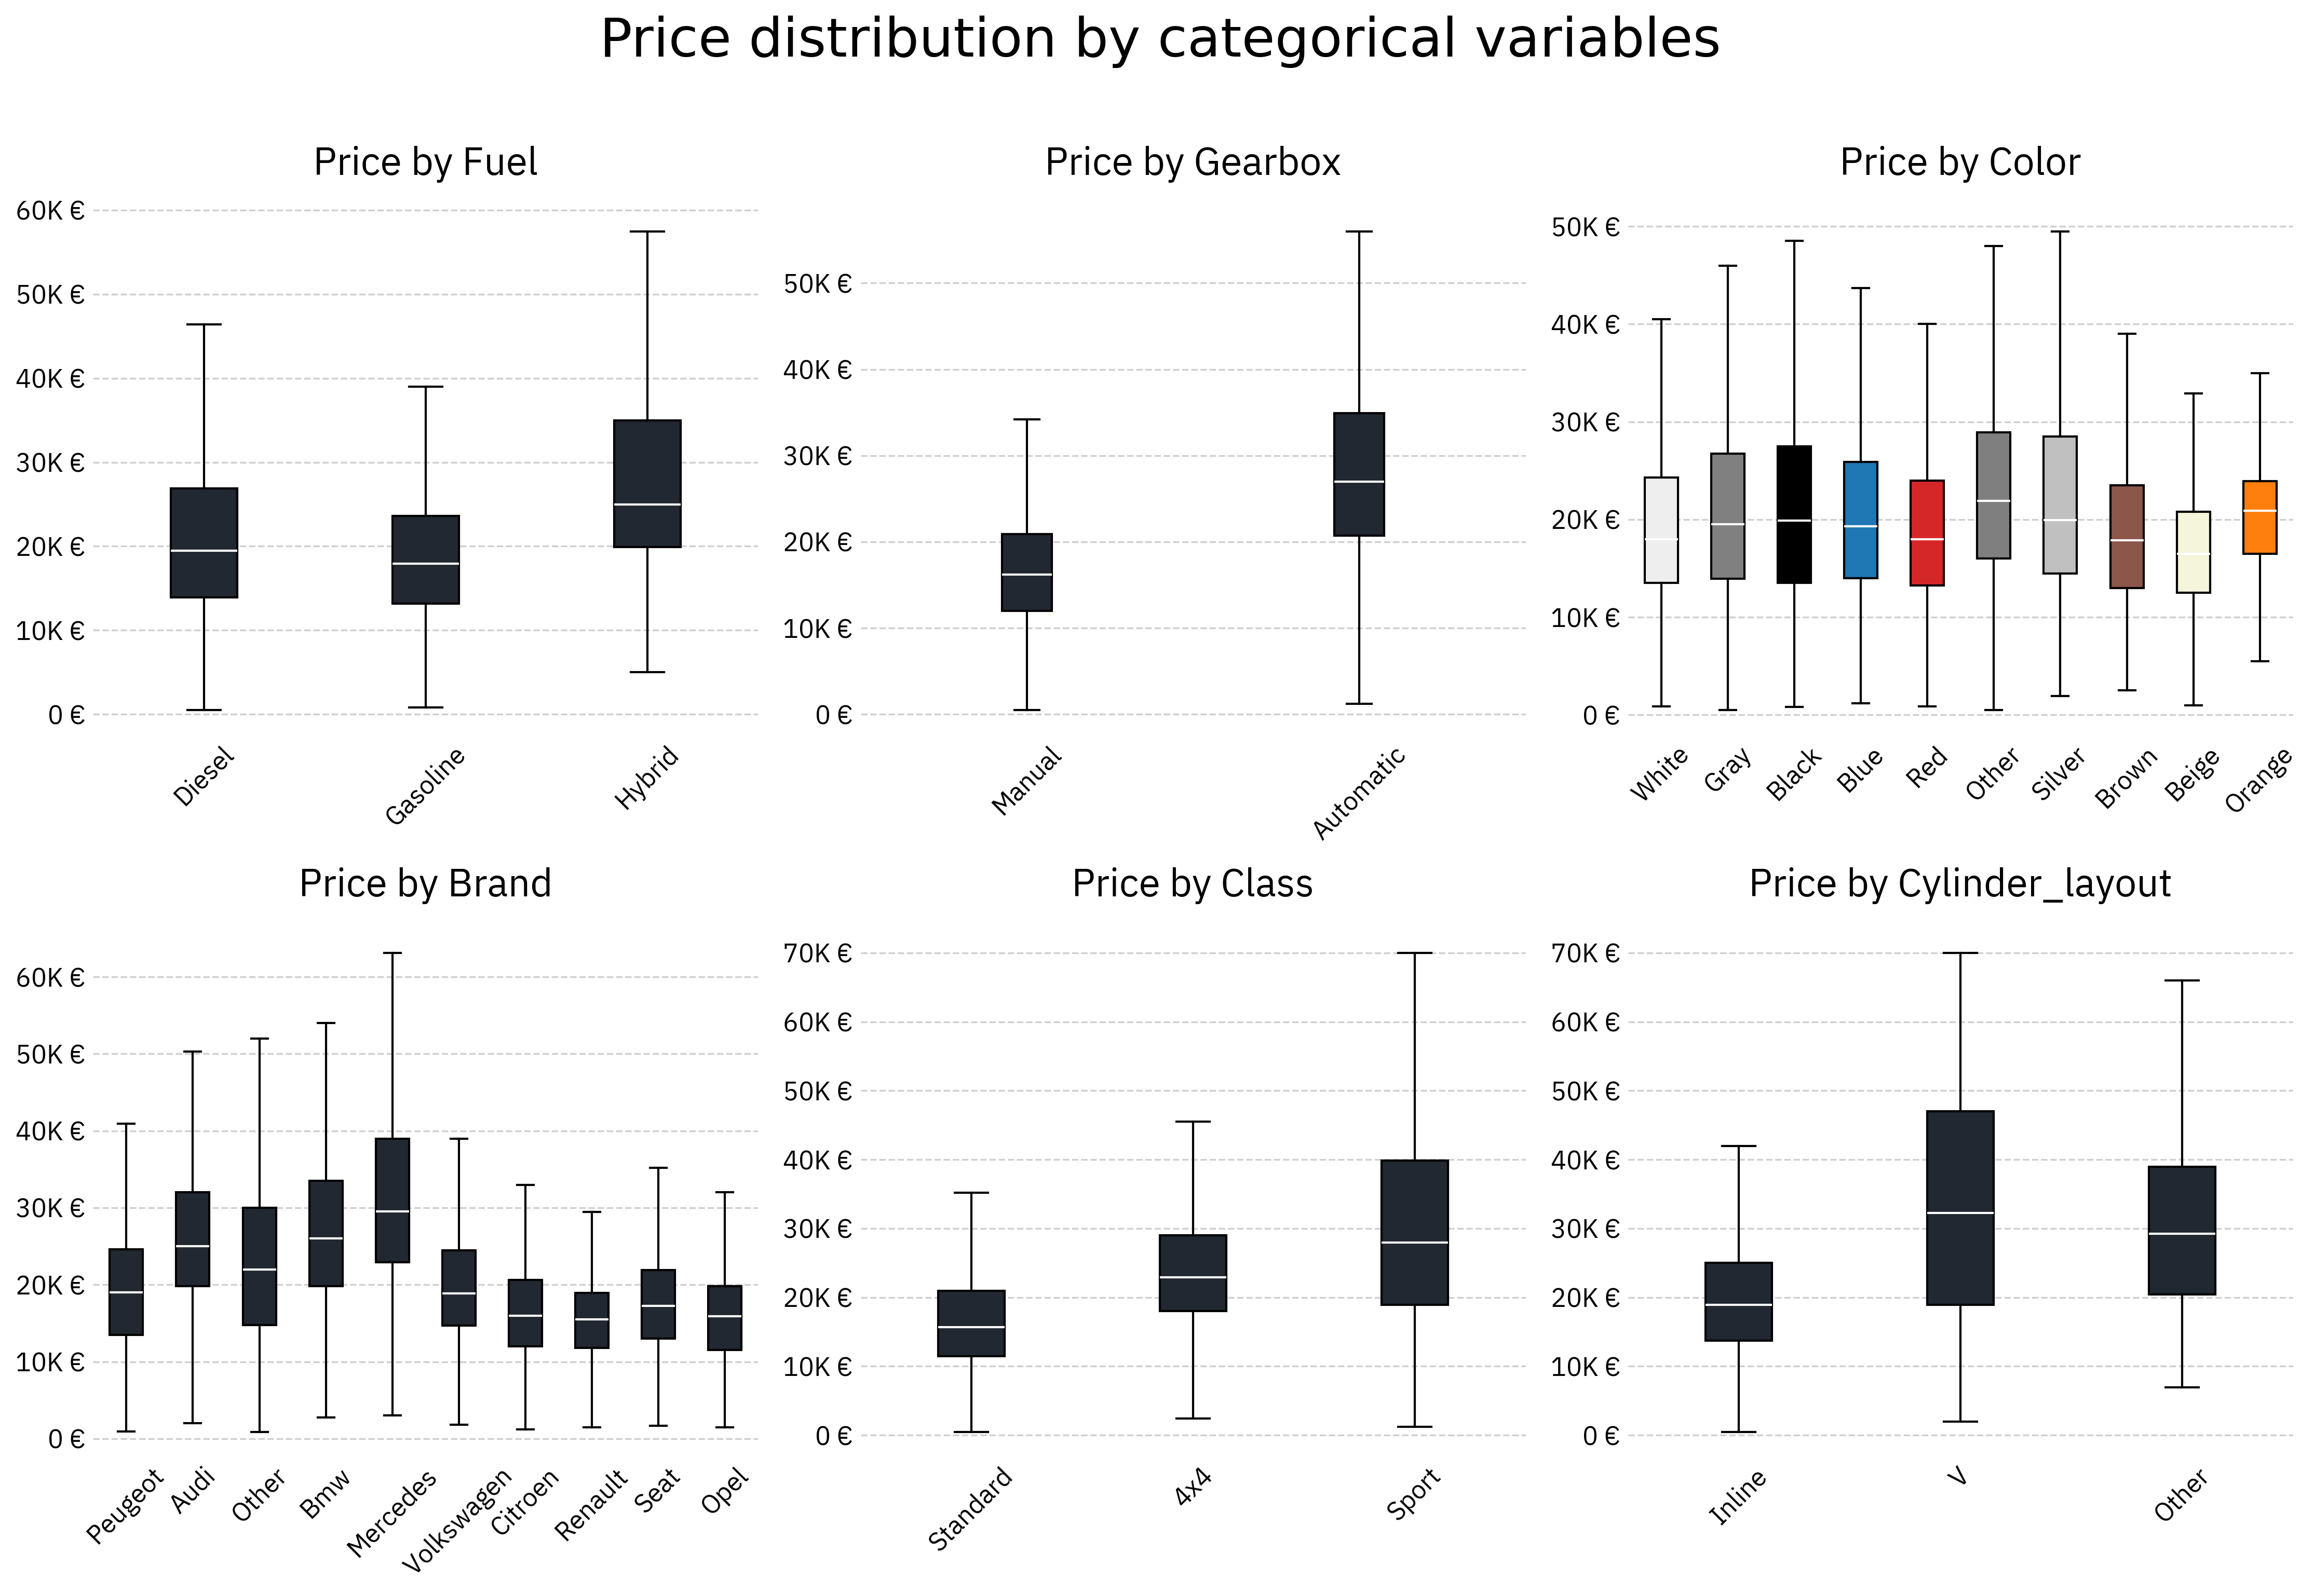

In [21]:
cats = [c for c in df.columns if (df[c].dtype == "object") and (c != "location")]
n_cols = 3
n_rows = math.ceil(len(cats) / n_cols)

color_map = {
    "White": "#EEEEEE",
    "Gray": "#808080",
    "Black": "#000000",
    "Blue": "#1F77B4",
    "Red": "#D62728",
    "Other": "#7F7F7F",
    "Silver": "#C0C0C0",
    "Brown": "#8C564B",
    "Beige": "#F5F5DC",
    "Orange": "#FF7F0E",
}
default_color = "#222831"

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5), dpi=300)
plt.subplots_adjust(hspace=2)
axes = axes.flatten() if len(cats) > 1 else [axes]
plt.suptitle("Price distribution by categorical variables", fontsize=25, y=1.02)

for i, col in enumerate(cats):
    top_10_cats = df[col].value_counts().head(10).index
    data_to_plot = []
    labels = []
    colors = []
    ax = axes[i]
    for cat in top_10_cats:
        prices = df[df[col] == cat]['price'].dropna()
        if not prices.empty:
            data_to_plot.append(prices)
            cat_label = str(cat).capitalize()
            labels.append(cat_label)
            if col == "color":
                colors.append(color_map.get(cat_label, default_color))
            else:
                colors.append(default_color)
                
    if data_to_plot:
        bplot = axes[i].boxplot(data_to_plot, tick_labels=labels, patch_artist=True, showfliers=False, medianprops=dict(color='white'))
        for patch, color in zip(bplot['boxes'], colors):
            patch.set_facecolor(color)

    sp.style_box(ax, title=f"Price by {col.capitalize()}", angle=45, vformat=sp.formats.currency(human=True))

for j in range(len(cats), len(axes)):
    fig.delaxes(axes[j])

sp.config.fontname = "IBM Plex Sans"
plt.tight_layout()
plt.show()

**Key Takeaways**:
- Several **Price** distributions are **clearly shifted**, indicating feature importance.
- **Brand** acts as a strong **structural prior** on price, consistent with market positioning rather than vehicle specs.
- **Color is not a primary pricing driver**, any differences are likely sampling noise.

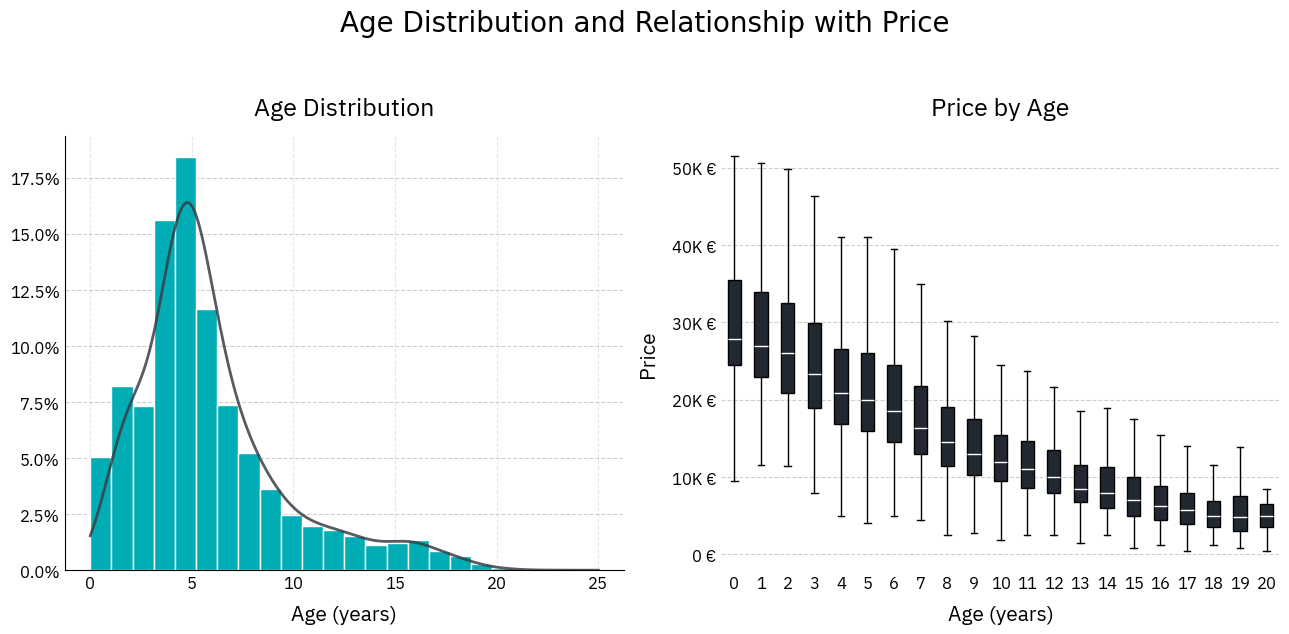

In [22]:

fig, axes = plt.subplots(1, 2, figsize=(13, 6), dpi=100)
plt.suptitle(f"Age Distribution and Relationship with Price", fontsize=20, y=1.05)

ax = axes[0]
plt.subplot(1, 2, 1)
plot_histogram(df["age"], bins=24, color_1="#00ADB5", color_2="#393E46", bw_adjust=2)
sp.style_hist(axes[0], yformat=sp.formats.percent(decimals=1), xformat=sp.formats.human(decimals=0), xtitle="Age (years)", title="Age Distribution")


data_to_plot = []
labels = []
counts = df[df.age<=20]['age'].value_counts().sort_index() # we filter low volume ages
for cat in counts.index:
    prices = df[df['age'] == cat]['price'].dropna()
    if not prices.empty:
        data_to_plot.append(prices)
        labels.append(str(cat).capitalize())
    
if data_to_plot:
    bplot = axes[1].boxplot(
        data_to_plot, 
        tick_labels=labels, 
        patch_artist=True, 
        showfliers=False, 
        medianprops=dict(color='white')
    )
    for patch in bplot['boxes']:
        patch.set_facecolor("#222831")


sp.style_box(axes[1], title=f"Price by Age", angle=0, xtitle="Age (years)", ytitle="Price", vformat=sp.formats.currency(human=True))
plt.tight_layout()
plt.show()

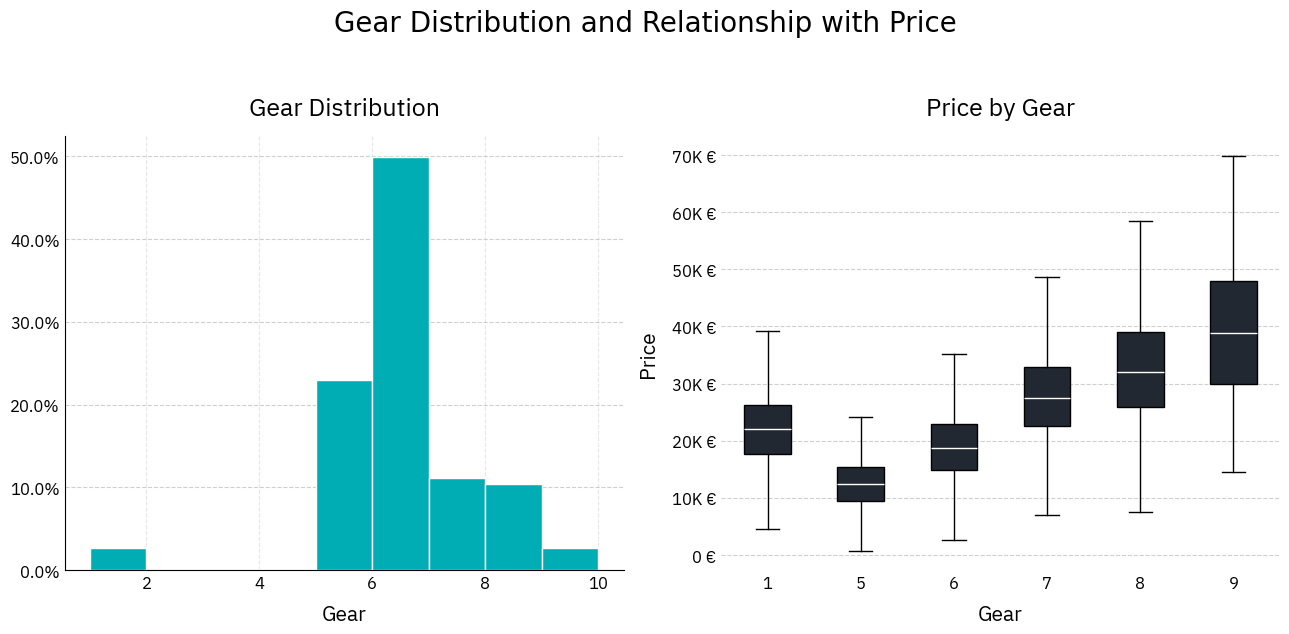

In [23]:

fig, axes = plt.subplots(1, 2, figsize=(13, 6), dpi=100)
plt.suptitle(f"Gear Distribution and Relationship with Price", fontsize=20, y=1.05)

ax = axes[0]
plt.subplot(1, 2, 1)
plot_histogram(df["gear"], bins=9, color_1="#00ADB5", color_2="#393E46", plot_kde=False)
sp.style_hist(axes[0], yformat=sp.formats.percent(decimals=1), xformat=sp.formats.human(decimals=0), xtitle="Gear", title="Gear Distribution")


data_to_plot = []
labels = []
counts = df['gear'].value_counts()
counts = counts[counts/len(df)>0.01].sort_index() 
for cat in counts.index:
    prices = df[df['gear'] == cat]['price'].dropna()
    if not prices.empty:
        data_to_plot.append(prices)
        labels.append(str(cat).capitalize())
    
if data_to_plot:
    bplot = axes[1].boxplot(
        data_to_plot, 
        tick_labels=labels, 
        patch_artist=True, 
        showfliers=False, 
        medianprops=dict(color='white')
    )
    for patch in bplot['boxes']:
        patch.set_facecolor("#222831")


sp.style_box(axes[1], title=f"Price by Gear", angle=0, xtitle="Gear", ytitle="Price", vformat=sp.formats.currency(human=True))
plt.tight_layout()
plt.show()

We can see how **the more gears a car has, the more expensive it is**. Nevertheless, there's one exception: cars with only 1 gear break the pattern (the reason being that they are likely to be hybrid cars, which are usually more expensive).

In [28]:
def plot_scatter(ax, df, x_col, target, color_1="#252A34", color_2="#FF2E63"):
    x = df[x_col].values
    y = df[target].values

    m, b = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)

    ax.scatter(x, y, marker="o", alpha=0.2, s=25, edgecolor="none", color=color_1, zorder=2)
    ax.plot(xs, m * xs + b, color=color_2, lw=1.5,    
            label=f"y = {m:.2f}x + {b:.2f}", zorder=3)
    ax.set_xlim(x.min()*0.9, x.max()*1.1)
    ax.set_ylim(y.min()*0.9, y.max()*1.15)
    return m

Feature              | Unit Increase   | AVG Price Difference
-------------------------------------------------------
cv                   | +1 horsepower   |  +122.56 €
km                   | +1 thousand km  |   -60.72 €
boot                 | +1 L            |   +28.37 €
length               | +1 cm           |  +155.78 €
width                | +1 cm           |  +779.85 €
max_sp               | +1 km/h         |  +259.50 €
cmixto               | +1 L            |  +984.10 €
displac              | +1 cm3          |    +8.46 €


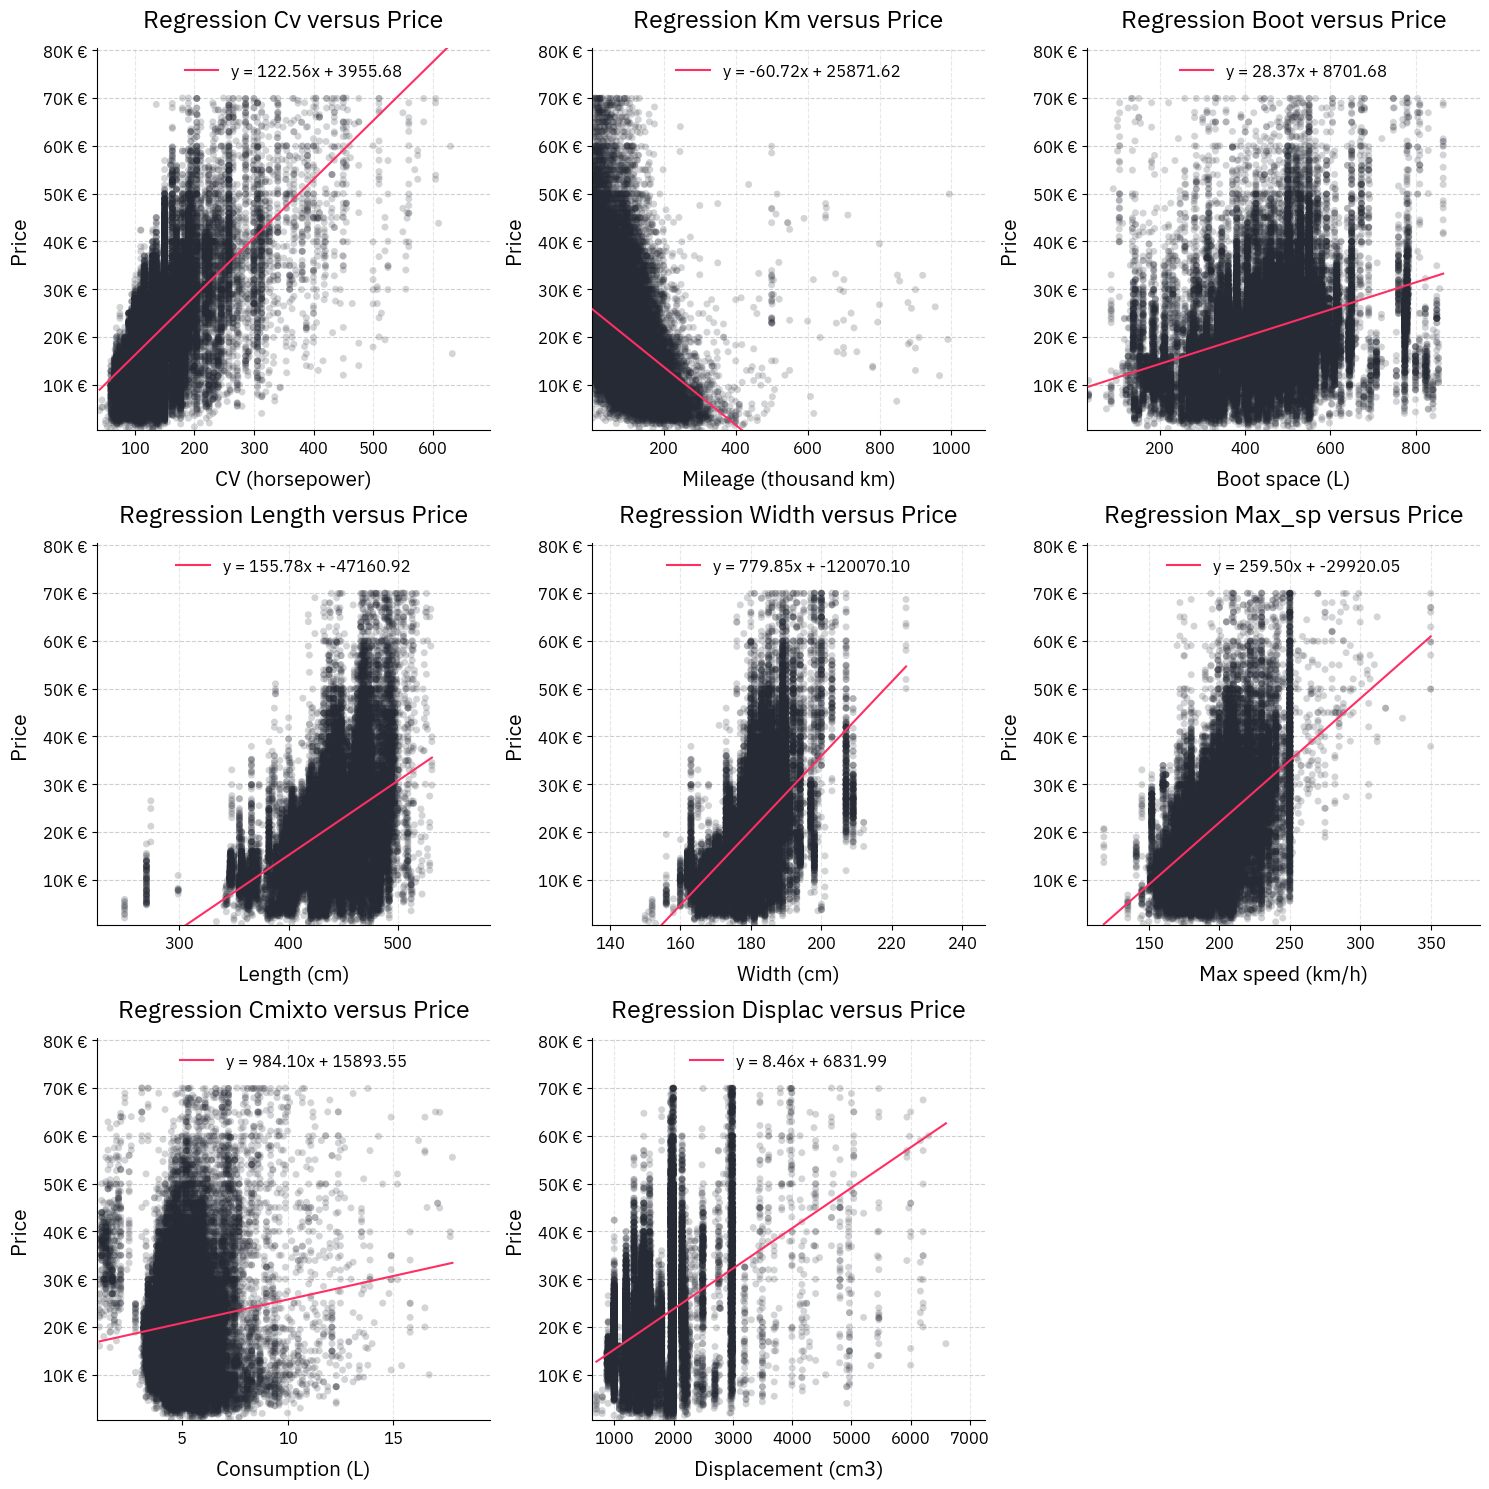

In [33]:
scatter_columns = ["cv", "km", "boot", "length", "width", "max_sp", "cmixto", "displac"]
map_units = {"cv": "horsepower", "km": "thousand km", "boot": "L", "length": "cm", "width": "cm", "max_sp": "km/h", "cmixto": "L", "displac": "cm3"}
map_names = {"cv": "CV", "km": "Mileage", "boot": "Boot space", "length": "Length", "width": "Width", "max_sp": "Max speed", "cmixto": "Consumption", "displac": "Displacement"}
cols = 3
num_plots = len(scatter_columns)
rows = math.ceil(num_plots / cols)
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = np.array(axes).flatten()
print(f"{'Feature':<20} | {'Unit Increase':<15} | {'AVG Price Difference':<15}")
print("-" * 55)
for i, col in enumerate(scatter_columns):
    ax = axes[i]
    m = plot_scatter(ax, df, col, "price")
    sp.style_line(
        ax, 
        yformat=sp.formats.currency(human=True, decimals=0), 
        title=f"Regression {col.capitalize()} versus Price", 
        xtitle=f"{map_names[col]} ({map_units[col]})", 
        ytitle="Price", 
        legend=True, 
        legend_loc="upper center",
        grid=True
    )
    unit_str = f"+1 {map_units[col]}"
    print(f"{col:<20} | {unit_str:<15} | {m:>+8.2f} €")
    
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Key takeaways**
- **Mileage** is the only **cleanly interpretable depreciation factor**, since it is largely independent of the spec feature.

>**⚠ Disclaimer ⚠**: These values come from separate univariate regressions, so each one reflects a feature together with everything it correlates with, not its isolated effect. It doesn't describe how price would change if you altered one spec while holding the rest. 
>
> In order to detect correctly the feature importance, correlation and true relationships, we would need to do multivariate analysis. For that, we could compute the Variance Inflation Factor (VIF) and isolate the real redundant features. Nevertheless, the **objective** of this project is **to predict the `price`**, not understand it. Hence, we will use a **tree-based model** (I already know it has a better acurracy from my first project version) and thus we  need not worry about having some multicollinearity.